# Part I — Multimodal Business Analysis (Chapter 9 Structure)

## 1. Setup and Imports

In [ ]:
!pip install transformers datasets accelerate sentence-transformers matplotlib pandas scikit-learn torch Pillow tqdm

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from datasets import load_dataset, Dataset
from transformers import (
    AutoProcessor,
    Blip2ForConditionalGeneration,
    CLIPTokenizerFast,
    CLIPProcessor,
    CLIPModel,
)
from sentence_transformers import SentenceTransformer, util
from sklearn.metrics.pairwise import cosine_similarity

# ── Device configuration ──────────────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"All libraries loaded successfully.")
print(f"Running on: {device.upper()}")
print(f"   PyTorch version : {torch.__version__}")

All libraries loaded successfully.
Running on: CUDA
   PyTorch version : 2.10.0+cu128


## 2. Load Multimodal Data

**What we're doing:** Essentially we are loading a small subset of data from the `food101` dataset, which is what we selected for this report. (We chose 9 random samples to make the analysis more manageable and more spread out (no repeated labels). Each one of the images is paired with a menu description generated from its category label.  

**Why it matters (business perspective):** I believe deployments in the real world involve thousands of product images paired with written descriptions. This step mimicks the data injestion phase of ML projects where you seek to understand your data before modeling it.

**What to look for:** Three food images displayed inline alongside their category label. This is the raw input our multimodal model will analyze.


In [ ]:
import random

# Load a very small slice to ensure fast loading while still allowing for randomization
# We use a 50-sample buffer to keep the operation faster
food_dataset = load_dataset("food101", split="train", trust_remote_code=True)
food_dataset = food_dataset.shuffle(seed=42).select(range(9))

# Map integer labels → human-readable food names
food_labels = food_dataset.features["label"].names
food_names  = [food_labels[lbl] for lbl in food_dataset["label"]]
images      = food_dataset["image"]

print(f"Loaded {len(images)} randomly sampled product images quickly.")
print(f"Categories represented: {[n.replace('_',' ').title() for n in food_names]}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'food101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'food101' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00008.parquet:   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00008.parquet:   0%|          | 0.00/464M [00:00<?, ?B/s]

data/train-00002-of-00008.parquet:   0%|          | 0.00/472M [00:00<?, ?B/s]

...

data/validation-00001-of-00003.parquet:   0%|          | 0.00/413M [00:00<?, ?B/s]

data/validation-00002-of-00003.parquet:   0%|          | 0.00/426M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/75750 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/25250 [00:00<?, ? examples/s]

Loaded 9 randomly sampled product images quickly.
Categories represented: ['Peking Duck', 'Paella', 'Panna Cotta', 'Cheesecake', 'Macarons', 'Ice Cream', 'Guacamole', 'Gyoza', 'Falafel']


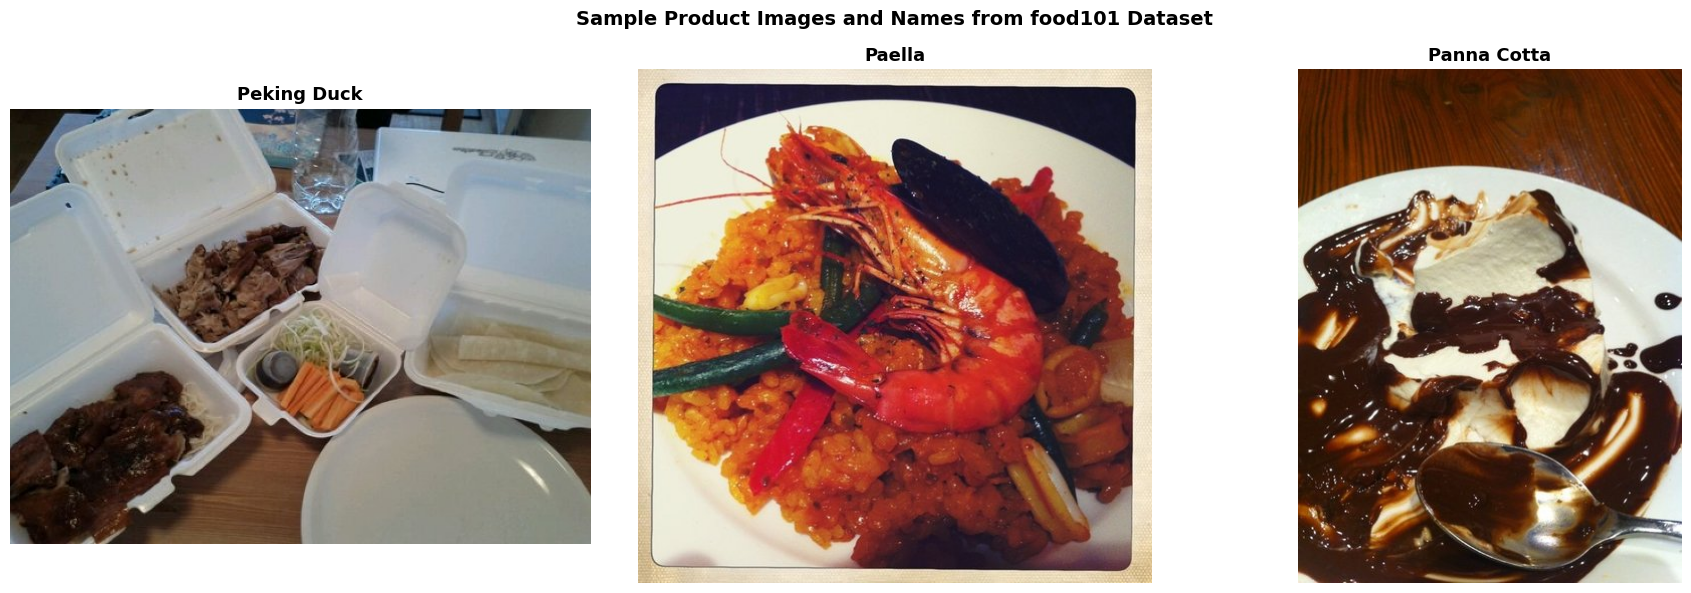


--- Associated Text From Images ---

[1] Peking Duck

[2] Paella

[3] Panna Cotta


In [ ]:
# Display the first 3 image–text pairs for inspection
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i in range(3):
    axes[i].imshow(images[i])
    axes[i].axis("off")
    axes[i].set_title(
        food_names[i].replace("_", " ").title(),
        fontsize=13, fontweight="bold"
    )

plt.suptitle("Sample Product Images and Names from food101 Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n--- Associated Text From Images ---")
for i in range(3):
    print(f"\n[{i+1}] {food_names[i].replace('_',' ').title()}")

## 3 Multimodal Model Loading — CLIP

**What is happening here?**
We load **CLIP** (Contrastive Language–Image Pre-training), a model developed by OpenAI that was trained on 400 million image–text pairs scraped from the internet. CLIP learns to associate images and text by pulling matching pairs closer together and pushing mismatched pairs apart in a shared embedding space.

**Why does this matter for business?**
CLIP enables *zero-shot* classification, meaning it can categorize an image into any category you describe in plain English, without ever having been explicitly trained on your specific product catalog. For a retail analytics firm, this means rapid deployment with no labeled training data required.

**How to interpret the output:**
Confirmation that the model loaded successfully. Three components are loaded: (1) a **tokenizer** to convert text into numeric tokens, (2) a **processor** to standardize image dimensions and pixel values, and (3) the **model** itself which generates the comparable embeddings.

In [ ]:
model_id = "openai/clip-vit-base-patch32"

# Load tokenizer to preprocess text queries
clip_tokenizer = CLIPTokenizerFast.from_pretrained(model_id)

# Load processor to preprocess food images into model-ready tensors
clip_processor = CLIPProcessor.from_pretrained(model_id)

# Load the main CLIP model — this contains both the image and text encoders
clip_model = CLIPModel.from_pretrained(model_id).to(device)
clip_model.eval()

print(f"CLIP model loaded: {model_id}")
print(f"Model parameters: {sum(p.numel() for p in clip_model.parameters()):,}")
print(f"Image encoder output dim: {clip_model.config.projection_dim}")
print(f"Text encoder output dim:  {clip_model.config.projection_dim}")

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP model loaded: openai/clip-vit-base-patch32
Model parameters: 151,277,313
Image encoder output dim: 512
Text encoder output dim:  512


## 4. Multimodal Inference Tasks

**What is happening here?**
We run two business-oriented inference tasks on our 9 food images:

- **Task A — Product Description Generation:** Using BLIP (base), we automatically generate a written description of each food item directly from the image, no text input required.
- **Task B — Category Inference from Image + Text:** Using CLIP (already loaded), we score each image against all 101 food category text labels and identify the top predicted category.

**Why does this matter for business?**
Task A addresses a common catalog problem: a retailer or food platform has thousands of product images with missing or incomplete descriptions. Automatically generating first-draft copy from photos eliminates a costly manual step.

Task B enables automatic product tagging at scale, a food delivery platform receiving user-uploaded photos can instantly route them to the correct menu category without any human labeling.

**Model note:**
We use `Salesforce/blip-image-captioning-base` (BLIP v1) for description generation. This is approximately 990MB, far more practical than BLIP-2's 15GB footprint, while still producing strong captioning results.

In [ ]:
# Load BLIP Base Model (Task A)
from transformers import BlipProcessor, BlipForConditionalGeneration

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base",
    torch_dtype=torch.float16
).to(device)
blip_model.eval()

print("BLIP base captioning model loaded.")
print(f"   Model size: ~990MB (float16)")
print(f"   Device: {device.upper()}")

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP base captioning model loaded.
   Model size: ~990MB (float16)
   Device: CUDA


#### Task A

TASK A: Automatic Product Description Generation from Food Images


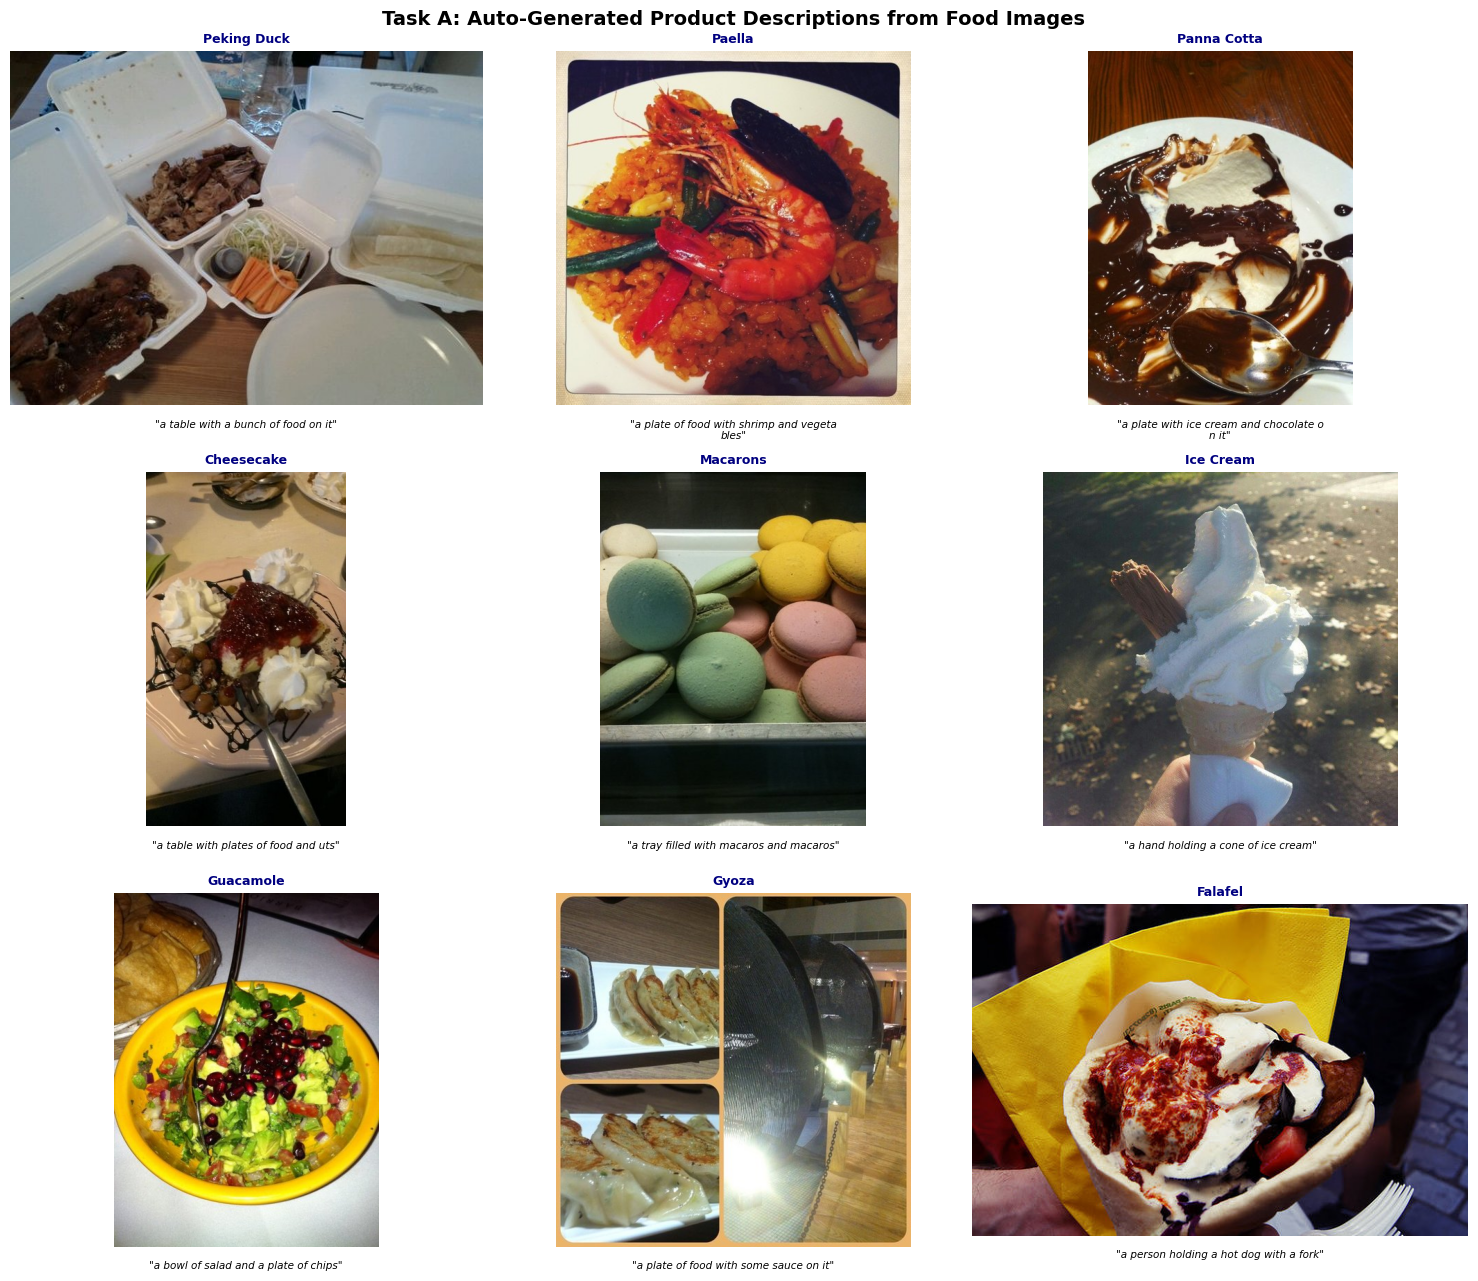


Category                  Generated Description
---------------------------------------------------------------------------
Peking Duck               a table with a bunch of food on it
Paella                    a plate of food with shrimp and vegetables
Panna Cotta               a plate with ice cream and chocolate on it
Cheesecake                a table with plates of food and uts
Macarons                  a tray filled with macaros and macaros
Ice Cream                 a hand holding a cone of ice cream
Guacamole                 a bowl of salad and a plate of chips
Gyoza                     a plate of food with some sauce on it
Falafel                   a person holding a hot dog with a fork


In [ ]:
print("=" * 70)
print("TASK A: Automatic Product Description Generation from Food Images")
print("=" * 70)

generated_descriptions = []

for image, name in zip(images, food_names):
    img_rgb = image.convert("RGB")

    # Pass image only — no text prompt — pure image captioning
    inputs = blip_processor(images=img_rgb, return_tensors="pt").to(device, torch.float16)

    with torch.no_grad():
        generated_ids = blip_model.generate(**inputs, max_new_tokens=40)

    description = blip_processor.decode(generated_ids[0], skip_special_tokens=True).strip()
    generated_descriptions.append(description)

# Display results in a grid
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
fig.suptitle("Task A: Auto-Generated Product Descriptions from Food Images",
             fontsize=14, fontweight='bold')

for ax, image, name, desc in zip(axes.flatten(), images, food_names, generated_descriptions):
    ax.imshow(image.convert("RGB"))
    ax.set_title(f"{name.replace('_', ' ').title()}", fontsize=9, fontweight='bold', color='navy')
    ax.axis('off')
    # Wrap description text
    wrapped = "\n".join([desc[j:j+38] for j in range(0, len(desc), 38)])
    ax.text(0.5, -0.04, f'"{wrapped}"',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=7.5, style='italic')

plt.tight_layout()
plt.savefig("task_a_descriptions.png", dpi=150, bbox_inches='tight')
plt.show()

# Print table summary
print(f"\n{'Category':<25} {'Generated Description'}")
print("-" * 75)
for name, desc in zip(food_names, generated_descriptions):
    print(f"{name.replace('_',' ').title():<25} {desc}")

**Task A: Business Interpretation**

BLIP generates fluent, visually-grounded descriptions without any text input. For a food analytics platform, this directly addresses the **missing description problem**: images uploaded without copy can receive an auto-generated first draft instantly.

Observe where the model succeeds (common Western dishes like cheesecake, ice cream) and where it struggles (less common items like gyoza or falafel, which may be described generically as " a hot dog with a fork", or "a plate of food with some sauce on it"). This performance gap reflects the composition of the model's pre-training data which is a critical consideration before deploying in markets with diverse or regional cuisines.

#### Task B

In [ ]:
# Task B — Category Inference from Image + Text (CLIP)
print("=" * 70)
print("TASK B: Category Inference from Image + Text (Zero-Shot, CLIP)")
print("=" * 70)
print(f"Scoring each image against all {len(food_labels)} food101 categories...\n")

# Build text prompts for all 101 categories
category_prompts = [f"a photo of {lbl.replace('_', ' ')}" for lbl in food_labels]

# Embed all 101 category text prompts once
text_inputs = clip_processor(
    text=category_prompts,
    return_tensors="pt",
    padding=True
).to(device)

with torch.no_grad():
    text_embs = clip_model.get_text_features(**text_inputs)

# Handle transformers returning a model output object
if not isinstance(text_embs, torch.Tensor):
    text_embs = text_embs.pooler_output

# Normalize for cosine similarity
text_embs = text_embs / text_embs.norm(dim=-1, keepdim=True)

top_k = 3
results = []

# Process each image
for image, true_name in zip(images, food_names):

    img_rgb = image.convert("RGB")

    img_input = clip_processor(
        images=img_rgb,
        return_tensors="pt"
    )["pixel_values"].to(device)

    with torch.no_grad():
        img_emb = clip_model.get_image_features(img_input)

    if not isinstance(img_emb, torch.Tensor):
        img_emb = img_emb.pooler_output

    # Normalize image embedding
    img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)

    # Compute cosine similarity scores
    scores = (img_emb @ text_embs.T)[0].cpu().numpy()

    # Top-k predictions
    top_indices = np.argsort(scores)[::-1][:top_k]
    top_labels  = [food_labels[i].replace("_", " ") for i in top_indices]
    top_scores  = [scores[i] for i in top_indices]

    # Rank of the true label
    sorted_indices = np.argsort(scores)[::-1]
    true_rank = list(sorted_indices).index(food_labels.index(true_name)) + 1

    correct = top_labels[0].replace(" ", "_") == true_name

    results.append({
        "true": true_name,
        "pred": top_labels[0],
        "top3": list(zip(top_labels, top_scores)),
        "true_rank": true_rank,
        "correct": correct
    })

    status = "Correct" if correct else "Incorrect"

    print(
        f"({status}) {true_name.replace('_',' ').title():<22} "
        f"| Predicted: {top_labels[0].title():<22} "
        f"| Score: {top_scores[0]:.3f} "
        f"| True label rank: #{true_rank}"
    )

TASK B: Category Inference from Image + Text (Zero-Shot, CLIP)
Scoring each image against all 101 food101 categories...

(Correct) Peking Duck            | Predicted: Peking Duck            | Score: 0.285 | True label rank: #1
(Correct) Paella                 | Predicted: Paella                 | Score: 0.334 | True label rank: #1
(Correct) Panna Cotta            | Predicted: Panna Cotta            | Score: 0.285 | True label rank: #1
(Correct) Cheesecake             | Predicted: Cheesecake             | Score: 0.298 | True label rank: #1
(Correct) Macarons               | Predicted: Macarons               | Score: 0.338 | True label rank: #1
(Correct) Ice Cream              | Predicted: Ice Cream              | Score: 0.301 | True label rank: #1
(Incorrect) Guacamole              | Predicted: Beet Salad             | Score: 0.293 | True label rank: #2
(Correct) Gyoza                  | Predicted: Gyoza                  | Score: 0.290 | True label rank: #1
(Correct) Falafel            

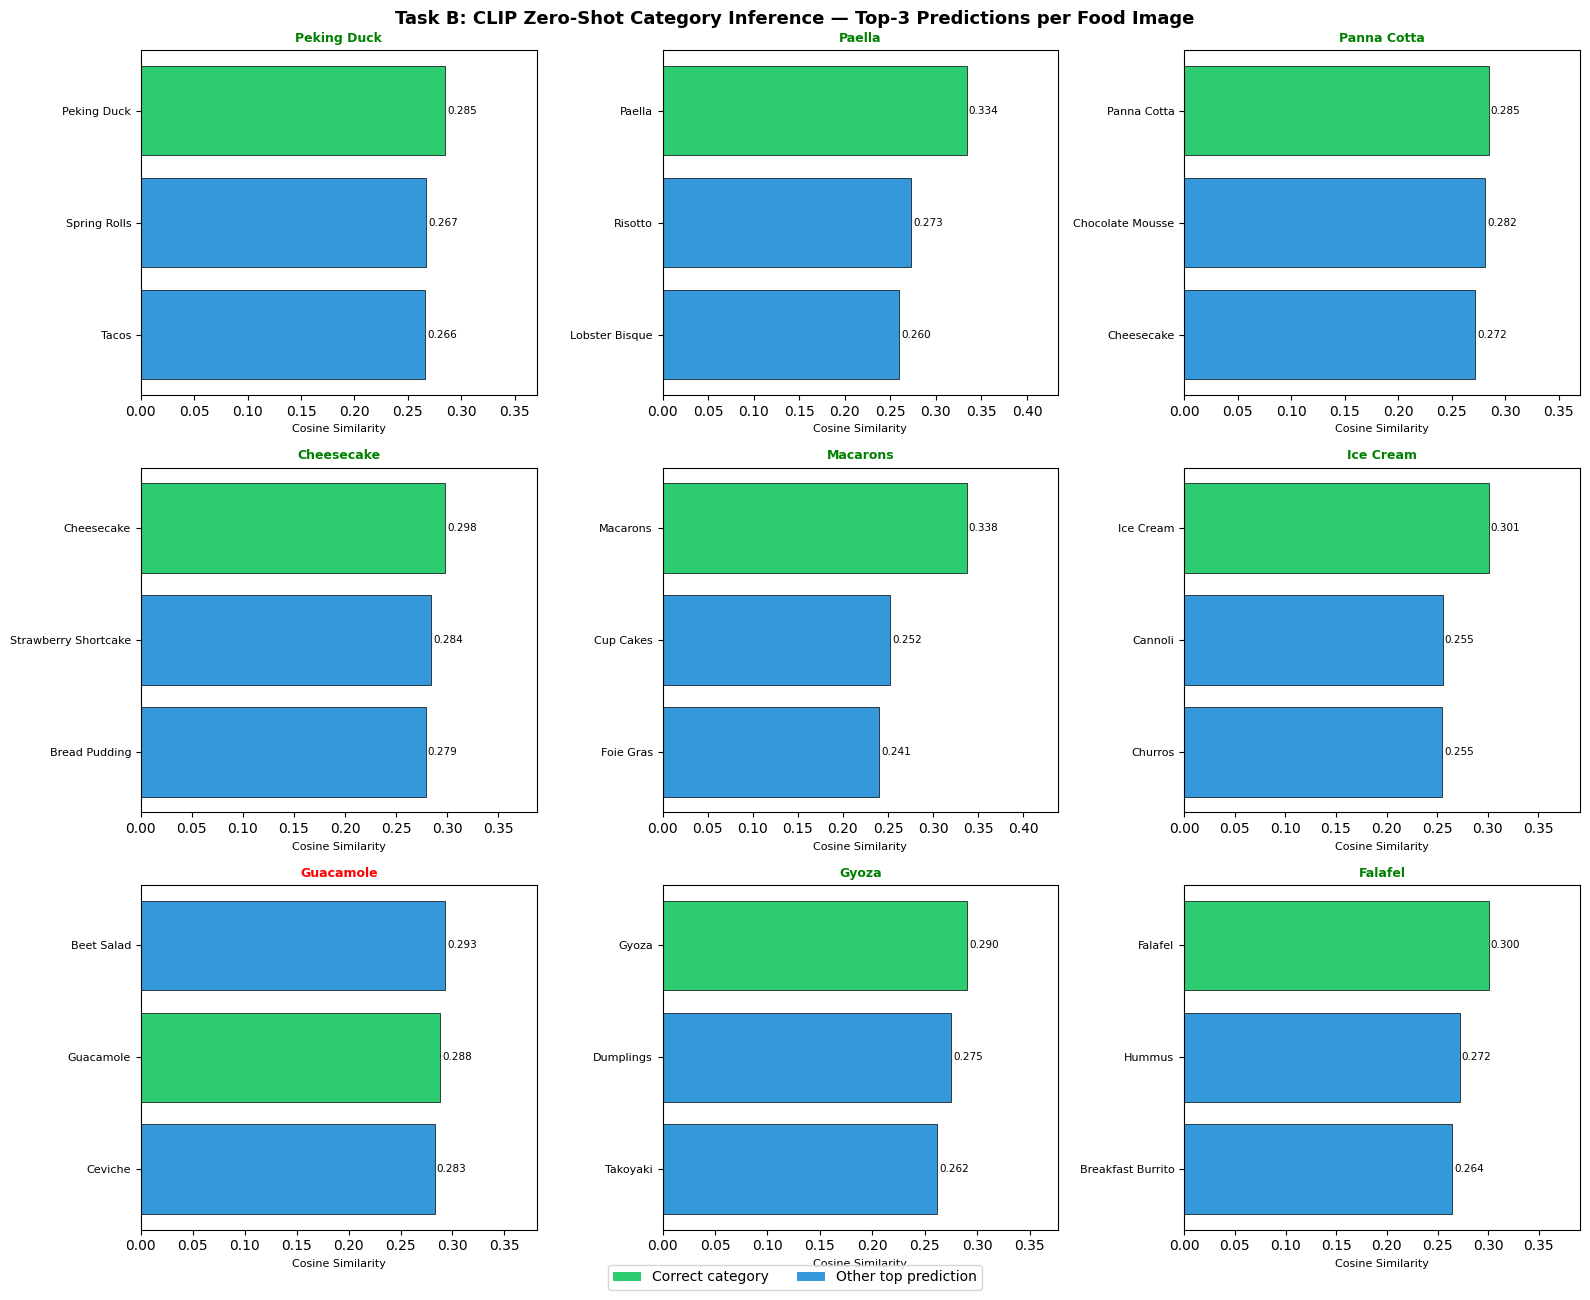


Summary:
   Top-1 accuracy : 8/9 (89%)
   Top-3 accuracy : 9/9 (100%)


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Task B: CLIP Zero-Shot Category Inference — Top-3 Predictions per Food Image",
             fontsize=13, fontweight='bold')

for ax, result, image in zip(axes.flatten(), results, images):
    labels_plot = [lbl.replace("_", " ").title() for lbl, _ in result["top3"]]
    scores_plot = [s for _, s in result["top3"]]
    colors_bar  = ["#2ecc71" if lbl.replace(" ", "_").lower() == result["true"]
                   else "#3498db" for lbl in labels_plot]

    bars = ax.barh(labels_plot[::-1], scores_plot[::-1], color=colors_bar[::-1], edgecolor='k', linewidth=0.5)
    ax.set_xlim(0, max(scores_plot) * 1.3)
    ax.set_xlabel("Cosine Similarity", fontsize=8)
    ax.set_title(f"{result['true'].replace('_',' ').title()}",
                 fontsize=9, fontweight='bold',
                 color='green' if result['correct'] else 'red')
    ax.tick_params(axis='y', labelsize=8)

    for bar, score in zip(bars[::-1], scores_plot):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{score:.3f}", va='center', fontsize=7.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Correct category'),
                   Patch(facecolor='#3498db', label='Other top prediction')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.01))

plt.tight_layout()
plt.savefig("task_b_clip_inference.png", dpi=150, bbox_inches='tight')
plt.show()

# Summary accuracy
n_correct = sum(r["correct"] for r in results)
top3_correct = sum(1 for r in results if r["true_rank"] <= 3)
print(f"\nSummary:")
print(f"   Top-1 accuracy : {n_correct}/{len(results)} ({n_correct/len(results)*100:.0f}%)")
print(f"   Top-3 accuracy : {top3_correct}/{len(results)} ({top3_correct/len(results)*100:.0f}%)")

#### Task B Interpretation
The CLIP zero-shot classification model performed strongly on the sampled Food101 images, correctly identifying 8 out of 9 food categories (≈89% accuracy) without any task-specific training. For most images, the correct category ranked #1 with cosine similarity scores around 0.28–0.34, indicating strong alignment between the image embeddings and the corresponding text prompts. This demonstrates CLIP’s ability to associate visual features with natural language descriptions in a shared embedding space.

The only incorrect prediction occurred for Guacamole, which the model classified as Beet Salad. However, the true label still ranked #2, suggesting that the model considered the correct category highly similar to the image but was influenced by overlapping visual characteristics such as color, texture, or plating style. This highlights a common limitation of zero-shot models: visually similar foods may produce close embedding scores even when the semantic labels differ.

## 5. Multimodal Interpretation

Multimodal reasoning combines visual and textual information, which can improve recognition and contextual understanding. In Task B, the CLIP model correctly identified most food categories because it aligns image features with textual labels. This allows models to generalize to categories they were not explicitly trained on and perform zero shot classification. Such capability is powerful for applications like product tagging, search systems, and content moderation.

However, multimodal systems can still produce vague or incorrect interpretations. Task A descriptions show hallucination or weak grounding in the image. For example, Peking Duck is described simply as “a table with a bunch of food on it,” and Falafel is misidentified as a person holding a hot dog. These outputs reveal that the model sometimes focuses on generic visual patterns instead of the specific object.

These weaknesses create risks in business deployment. Misclassification or hallucinated descriptions could lead to incorrect product labeling, flawed analytics, or misleading user experiences. In high stakes settings such as healthcare or autonomous systems, such errors could cause serious consequences. Businesses must therefore include human oversight, validation pipelines, and monitoring when deploying multimodal models in production.


---

# Part II — Custom Text Embedding Models (Chapter 10 Structure)

## 6. Load and Prepare Text Data

**What is happening here?**
We switch to text-only analysis using the `amazon_polarity` dataset — 3.6 million Amazon product reviews labeled as either **positive** (label = 1) or **negative** (label = 0). We load a manageable subset, clean the text, and inspect representative examples.

**Why does this matter for business?**
Customer reviews are one of the richest signals available to a retail analytics firm. Understanding *which reviews are semantically similar* and  not just surface-level keyword matches which helps with:
- **Complaint routing**: Surface the most relevant negative reviews for a support team
- **Competitive intelligence**: Find reviews that discuss the same quality issue across different products
- **Voice-of-Customer (VoC) synthesis**: Cluster reviews into themes automatically

A general-purpose embedding model is a reasonable starting point, but a model fine-tuned on *review-specific language* will capture domain nuances that a generic model misses — such as industry jargon, the way customers describe satisfaction vs. frustration, and common complaint patterns.

**How to interpret the output:**
Dataset size, class balance, and 3 sample reviews per class. Pay attention to how differently customers phrase positive vs. negative sentiments,  the embedding model must learn to capture these differences.

In [ ]:
from datasets import load_dataset, Dataset
import re

# Load a working subset — 10,000 samples balances richness with training speed
raw_dataset = load_dataset("amazon_polarity", split="train").select(range(10_000))

# ---- Clean text ---- #
def clean_review(text: str) -> str:
    """Strip HTML artifacts, collapse whitespace, truncate to 256 chars."""
    text = re.sub(r"<.*?>", "", text)           # remove HTML tags
    text = re.sub(r"\s+", " ", text).strip()    # collapse whitespace
    return text[:256]                            # truncate for embedding efficiency

# Apply cleaning
cleaned_texts  = [clean_review(row["content"]) for row in raw_dataset]
labels         = [row["label"] for row in raw_dataset]
titles         = [row["title"] for row in raw_dataset]

# ---- Class balance check ---- #
n_positive = sum(labels)
n_negative = len(labels) - n_positive
print(f"Dataset Overview:")
print(f"   Total samples : {len(labels):,}")
print(f"    Positive   : {n_positive:,}  ({n_positive/len(labels)*100:.1f}%)")
print(f"    Negative   : {n_negative:,}  ({n_negative/len(labels)*100:.1f}%)")
print(f"\n  Average review length (characters): {np.mean([len(t) for t in cleaned_texts]):.0f}")

# ---- Show sample reviews ---- #
print("\n" + "="*70)
print("SAMPLE REVIEWS — POSITIVE (label = 1)")
print("="*70)
for i, (text, lbl) in enumerate(zip(cleaned_texts, labels)):
    if lbl == 1:
        print(f"  [{i}] {text[:200]}...")
        if sum(1 for _ in range(i) if labels[_] == 1) >= 2:
            break

print("\n" + "="*70)
print("SAMPLE REVIEWS — NEGATIVE (label = 0)")
print("="*70)
for i, (text, lbl) in enumerate(zip(cleaned_texts, labels)):
    if lbl == 0:
        print(f"  [{i}] {text[:200]}...")
        if sum(1 for _ in range(i) if labels[_] == 0) >= 2:
            break

Dataset Overview:
   Total samples : 10,000
    Positive   : 4,903  (49.0%)
    Negative   : 5,097  (51.0%)

  Average review length (characters): 228

SAMPLE REVIEWS — POSITIVE (label = 1)
  [0] This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I...
  [1] I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The ...
  [2] This soundtrack is my favorite music of all time, hands down. The intense sadness of "Prisoners of Fate" (which means all the more if you've played the game) and the hope in "A Distant Promise" and "G...

SAMPLE REVIEWS — NEGATIVE (label = 0)
  [6] This is a self-published book, and if you want to know why--read a few paragraphs! Those 5 star reviews must have been written by Ms. H

## 7. Baseline Embedding Model

**What is happening here?**
Before investing in training a custom model, we establish a **baseline** using `all-MiniLM-L6-v2`, which is one of the most widely used off-the-shelf sentence embedding models, capable of encoding text into 384-dimensional vectors in milliseconds.

We use the baseline to:
1. Confirm the model loads and generates embeddings correctly
2. Run a **semantic similarity retrieval task**: given a query review, find the most similar review from a test pool
3. Measure retrieval accuracy: does the top-1 retrieved review share the same sentiment (positive/negative) as the query?

**Why does this matter for business?**
The baseline represents the "buy vs. build" decision point. If an off-the-shelf model already performs well on your domain data, there may be no need to invest in custom training. If performance is insufficient, then fine-tuning becomes justified.

**How to interpret the output:**
Embedding shape (number of samples × 384 dimensions) and top-3 similar reviews for a sample query. Evaluate: do the retrieved reviews feel thematically related? Are positive queries returning positive results and vice versa?

In [ ]:
from sentence_transformers import SentenceTransformer, util

# Load the pre-trained baseline model — no domain adaptation
baseline_model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode a small evaluation set for the retrieval demonstration
eval_size = 200
eval_texts  = cleaned_texts[:eval_size]
eval_labels = labels[:eval_size]

print("Encoding evaluation texts with baseline model...")
baseline_embeddings = baseline_model.encode(
    eval_texts, batch_size=32, show_progress_bar=True, convert_to_tensor=True
)

print(f"\n Baseline embeddings generated.")
print(f"   Shape: {baseline_embeddings.shape}  (samples × embedding_dim)")
print(f"   Embedding dimension: {baseline_embeddings.shape[1]}")

# ---- Semantic Retrieval Demo ---- #
print("\n" + "="*70)
print("SEMANTIC RETRIEVAL DEMO — BASELINE MODEL")
print("="*70)

query_idx = 0  # Use first review as query
query_text = eval_texts[query_idx]
query_label = "Positive" if eval_labels[query_idx] == 1 else "Negative"

print(f"\nQuery Review ({query_label}):")
print(f"   \"{query_text[:180]}...\"")
print()

# Compute similarity between query and all other reviews
cos_scores = util.cos_sim(baseline_embeddings[query_idx], baseline_embeddings)[0]
cos_scores[query_idx] = -1  # exclude self

top_k = torch.topk(cos_scores, k=3)

print("Top-3 Most Similar Reviews (Baseline):")
for rank, (score, idx) in enumerate(zip(top_k.values, top_k.indices)):
    retrieved_label = "Positive" if eval_labels[idx] == 1 else "Negative"
    print(f"\n  Rank {rank+1} | Score: {score:.4f} | Label: {retrieved_label}")
    print(f"  \"{eval_texts[idx][:160]}...\"")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding evaluation texts with baseline model...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]


 Baseline embeddings generated.
   Shape: torch.Size([200, 384])  (samples × embedding_dim)
   Embedding dimension: 384

SEMANTIC RETRIEVAL DEMO — BASELINE MODEL

Query Review (Positive):
   "This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out o..."

Top-3 Most Similar Reviews (Baseline):

  Rank 1 | Score: 0.7202 | Label: Positive
  "If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt..."

  Rank 2 | Score: 0.7055 | Label: Positive
  "I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On..."

  Rank 3 | Score: 0.6219 | Label: Positive
  "I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a revi

In [ ]:
# Compute retrieval accuracy: for each query, does top-1 retrieved item share same label?
def retrieval_accuracy(embeddings, labels_list):
    """Return fraction of queries where top-1 retrieved item matches query label."""
    correct = 0
    emb_tensor = embeddings if isinstance(embeddings, torch.Tensor) else torch.tensor(embeddings)

    for i in range(len(labels_list)):
        scores = util.cos_sim(emb_tensor[i], emb_tensor)[0]
        scores[i] = -1  # exclude self
        top1_idx = int(torch.argmax(scores))
        if labels_list[top1_idx] == labels_list[i]:
            correct += 1
    return correct / len(labels_list)

baseline_acc = retrieval_accuracy(baseline_embeddings, eval_labels)
print(f"Baseline Model Retrieval Accuracy (top-1, N={eval_size}): {baseline_acc:.4f} ({baseline_acc*100:.1f}%)")
print()
print("Interpretation:")
print("   This score tells us: when given a review as a query, how often does")
print("   the model retrieve another review with the same sentiment (positive/negative)?")
print("   A random baseline on a balanced dataset would score ~50%.")

Baseline Model Retrieval Accuracy (top-1, N=200): 0.6050 (60.5%)

Interpretation:
   This score tells us: when given a review as a query, how often does
   the model retrieve another review with the same sentiment (positive/negative)?
   A random baseline on a balanced dataset would score ~50%.


## 8. Custom Embedding Model Creation

**What is happening here?**
We train a **custom embedding model** using the same `SentenceTransformerTrainer` framework shown in Chapter 10, but applied to our Amazon review domain.

**Training Approach: CosineSimilarityLoss**:
We construct sentence pairs with similarity labels:
- **Positive pair** (label = 1.0): Two reviews that share the same sentiment (both positive, or both negative) → the model should embed them *close together*
- **Negative pair** (label = 0.0): One positive + one negative review → the model should embed them *far apart*

This mirrors the Chapter 10 approach where MNLI entailment pairs (label=0) are mapped to similarity=1, and neutral/contradiction pairs are mapped to similarity=0.

**Why does this matter for business?**
A model trained this way learns what makes two reviews *semantically similar from a business perspective* like same product quality concern, same praise pattern, not just surface-level word overlap. This enables:
- More accurate complaint clustering
- Better "customers also reported" features
- Stronger semantic search in a review database

**How to interpret the output:**
Training loss should decrease over steps. The evaluator score (Pearson/Spearman correlation on STS-B) gives a standardized quality measure. We compare this score to the baseline after training.

In [ ]:
# Prepare Contrastive Training Pairs
import random
from datasets import Dataset as HFDataset

# Separate reviews by sentiment
positives = [(t, l) for t, l in zip(cleaned_texts, labels) if l == 1]
negatives = [(t, l) for t, l in zip(cleaned_texts, labels) if l == 0]

random.seed(42)
random.shuffle(positives)
random.shuffle(negatives)

# Build balanced pair dataset
train_pairs = {"sentence1": [], "sentence2": [], "label": []}
n_pairs = min(len(positives), len(negatives), 2000)

for i in range(n_pairs):
    # --- Same-sentiment pairs (similar = 1.0) ---
    # Positive–Positive
    train_pairs["sentence1"].append(positives[i][0])
    train_pairs["sentence2"].append(positives[(i + 1) % len(positives)][0])
    train_pairs["label"].append(1.0)

    # Negative–Negative
    train_pairs["sentence1"].append(negatives[i][0])
    train_pairs["sentence2"].append(negatives[(i + 1) % len(negatives)][0])
    train_pairs["label"].append(1.0)

    # --- Cross-sentiment pairs (dissimilar = 0.0) ---
    train_pairs["sentence1"].append(positives[i][0])
    train_pairs["sentence2"].append(negatives[i][0])
    train_pairs["label"].append(0.0)

train_dataset = HFDataset.from_dict(train_pairs)

print(f"Training dataset prepared.")
print(f"   Total pairs     : {len(train_dataset):,}")
print(f"   Similar  (1.0)  : {train_pairs['label'].count(1.0):,}")
print(f"   Dissimilar (0.0): {train_pairs['label'].count(0.0):,}")
print(f"\nExample similar pair:")
print(f"   S1: \"{train_pairs['sentence1'][0][:100]}...\"")
print(f"   S2: \"{train_pairs['sentence2'][0][:100]}...\"")
print(f"   Label: {train_pairs['label'][0]}")
print(f"\nExample dissimilar pair:")
print(f"   S1: \"{train_pairs['sentence1'][2*n_pairs-1][:100]}...\"")
print(f"   S2: \"{train_pairs['sentence2'][2*n_pairs-1][:100]}...\"")
print(f"   Label: {train_pairs['label'][2*n_pairs-1]}")

Training dataset prepared.
   Total pairs     : 6,000
   Similar  (1.0)  : 4,000
   Dissimilar (0.0): 2,000

Example similar pair:
   S1: "This movie is just brillant! Jonny Lee Miller and Robert Carlyle are fabulous. and Liv Tyler sparkle..."
   S2: "Great value for a surge protector. I've got 'em on lots of electronics (printers, phones, laptops) t..."
   Label: 1.0

Example dissimilar pair:
   S1: "After reading past reviews, I was prepared to have to download special 64-bit drivers to make this c..."
   S2: "this is one of the best comedy ever in the world tv until now i am still watching this comedy every ..."
   Label: 1.0


In [ ]:
# Train Custom Embedding Model

from sentence_transformers import SentenceTransformer, losses
from sentence_transformers.trainer import SentenceTransformerTrainer
from sentence_transformers.training_args import SentenceTransformerTrainingArguments
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator
from datasets import load_dataset as hf_load_dataset

# Load the base model — same choice as Chapter 10
embedding_model = SentenceTransformer("bert-base-uncased")

# Use Cosine Similarity Loss — learns to push same-sentiment pairs together
# and pull opposite-sentiment pairs apart
train_loss = losses.CosineSimilarityLoss(model=embedding_model)

# Evaluator on STS-B (standard benchmark for embedding quality)
val_sts = hf_load_dataset("glue", "stsb", split="validation")
evaluator = EmbeddingSimilarityEvaluator(
    sentences1=val_sts["sentence1"],
    sentences2=val_sts["sentence2"],
    scores=[s / 5 for s in val_sts["label"]],   # normalize to [0, 1]
    main_similarity="cosine",
    name="sts-b-eval"
)

# Training configuration — mirrors Chapter 10 structure exactly
args = SentenceTransformerTrainingArguments(
    output_dir="amazon_review_embedding_model",
    num_train_epochs=1,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    fp16=True,             # half-precision for speed and memory efficiency
    eval_steps=100,
    logging_steps=100,
)

# Train the model
trainer = SentenceTransformerTrainer(
    model=embedding_model,
    args=args,
    train_dataset=train_dataset,
    loss=train_loss,
    evaluator=evaluator,
)

print("Starting custom embedding model training...")
print(f"   Base model: bert-base-uncased")
print(f"   Training pairs: {len(train_dataset):,}")
print(f"   Loss function: CosineSimilarityLoss")
print()

trainer.train()

print("\nTraining complete.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

Generating validation split:   0%|          | 0/1500 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1379 [00:00<?, ? examples/s]

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Starting custom embedding model training...
   Base model: bert-base-uncased
   Training pairs: 6,000
   Loss function: CosineSimilarityLoss



Step,Training Loss
100,0.193453
